In [1]:
import palantir
import scanpy as sc
import scvelo as scv
import pandas as pd
import numpy as np
import os
import sys
import cellrank as cr
# Plotting
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rcParams

# warnings
import warnings
from numba.core.errors import NumbaDeprecationWarning

warnings.filterwarnings(action="ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings(
    action="ignore", module="scanpy", message="No data for colormapping"
)

# Inline plotting
%matplotlib inline

/home/xcl/anaconda3/envs/cellrank/lib/python3.9/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
sc.settings.verbosity = 4
sc.set_figure_params(dpi=80, dpi_save=300, facecolor='white') 
sc.logging.print_header()

scanpy==1.9.8 anndata==0.10.5.post1 umap==0.5.5 numpy==1.26.4 scipy==1.13.0 pandas==2.2.2 scikit-learn==1.1.3 statsmodels==0.14.1 igraph==0.11.4 pynndescent==0.5.11


In [4]:
df = pd.read_csv('/home/xcl/KPM/LUAD_Inter_SCLC-3-20.csv', index_col=0)

In [5]:
df = np.transpose(df)

In [6]:
cellinfo = pd.DataFrame(df.index,index=df.index,columns=['sample_index'])
geneinfo = pd.DataFrame(df.columns,index=df.columns,columns=['genes_index'])
ad = sc.AnnData(df, obs=cellinfo, var = geneinfo)

In [7]:
sc.pp.normalize_total(ad)

normalizing counts per cell
    finished (0:00:00)


In [8]:
palantir.preprocess.log_transform(ad)

In [9]:
sc.pp.highly_variable_genes(ad, n_top_genes=1500, flavor="cell_ranger")

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    the 1500 top genes correspond to a normalized dispersion cutoff of 2.487084405810675
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [10]:
highly_variable_genes = ad.var.index[ad.var['highly_variable']]

In [11]:
highly_variable_genes

Index(['Rp1', 'Alkal1', 'Msc', 'Trpa1', 'Gm16070', 'Tram2', 'Gm28836',
       'Gm29128', 'Gm33280', 'Zap70',
       ...
       'H2al1b', 'Dcaf12l2', '4933402E13Rik', 'Gpr50', 'Gm5941', 'Taf7l',
       'Kcne1l', 'Gm15201', 'Grpr', 'Gm8817'],
      dtype='object', length=1500)

In [12]:
highly_variable_genes_table=pd.DataFrame(highly_variable_genes)
highly_variable_genes_table.to_csv("highly_variable_genes_table_3-3-26.csv",index=False)

In [13]:
# Note in the manuscript, we did not use highly variable genes but scanpy by default uses only highly variable genes
sc.pp.pca(ad)

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PC1', 'PC2', ..., the loadings (adata.var)
    'pca_variance', the variance / eigenvalues (adata.uns)
    'pca_variance_ratio', the variance ratio (adata.uns)


In [14]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(ad, n_components=5)

computing neighbors
    computing neighbors
    computed neighbors (0:00:00)
    computed connectivities (0:00:02)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)


In [15]:
ms_data = palantir.utils.determine_multiscale_space(ad)

In [16]:
sc.pp.neighbors(ad)
sc.tl.umap(ad)

computing neighbors
    computing neighbors
    using 'X_pca' with n_pcs = 50
    computed neighbors (0:00:01)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP


  0%|          | 0/500 [00:00<?, ?it/s]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:09)


In [17]:
sc.tl.draw_graph(ad)

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:00:45)


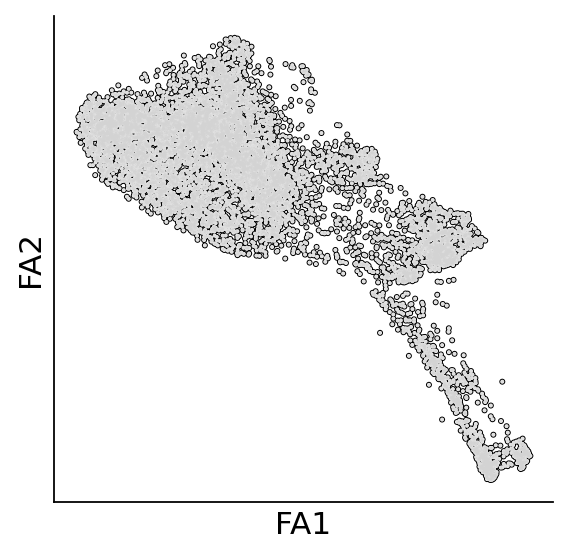

In [18]:
sc.pl.draw_graph(ad, s=10, add_outline=True,save="fa-epi-3-26.png")

In [19]:
imputed_X = palantir.utils.run_magic_imputation(ad)

/home/xcl/anaconda3/envs/cellrank/lib/python3.9/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
/home/xcl/anaconda3/envs/cellrank/lib/python3.9/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
/home/xcl/anaconda3/envs/cellrank/lib/python3.9/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe

running Leiden clustering
    finished: found 3 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:02)


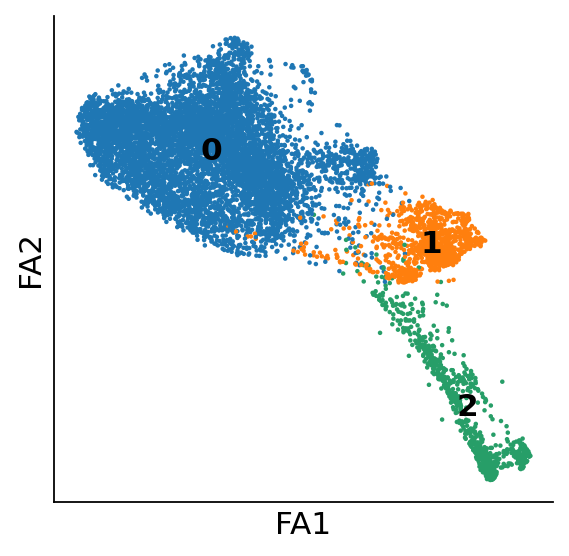

In [20]:
# Leiden
sc.tl.leiden(ad, resolution=0.1)
sc.pl.draw_graph(ad, color='leiden', legend_loc='on data',title = "")

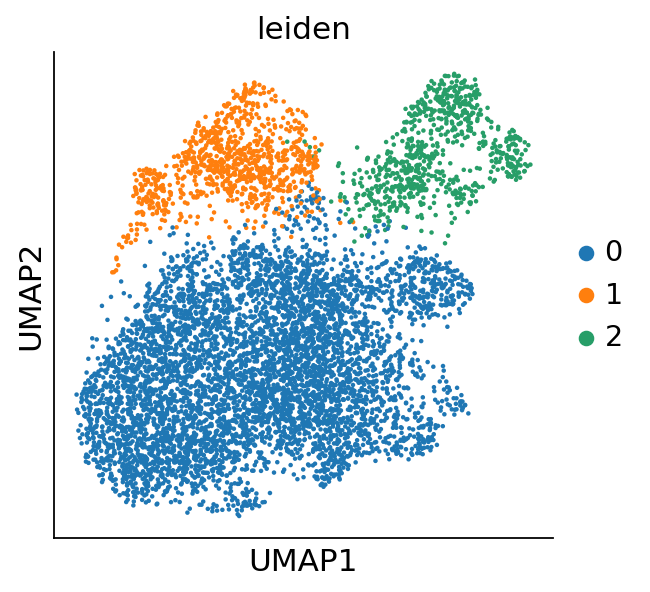

In [21]:
sc.pl.umap(ad, color='leiden')

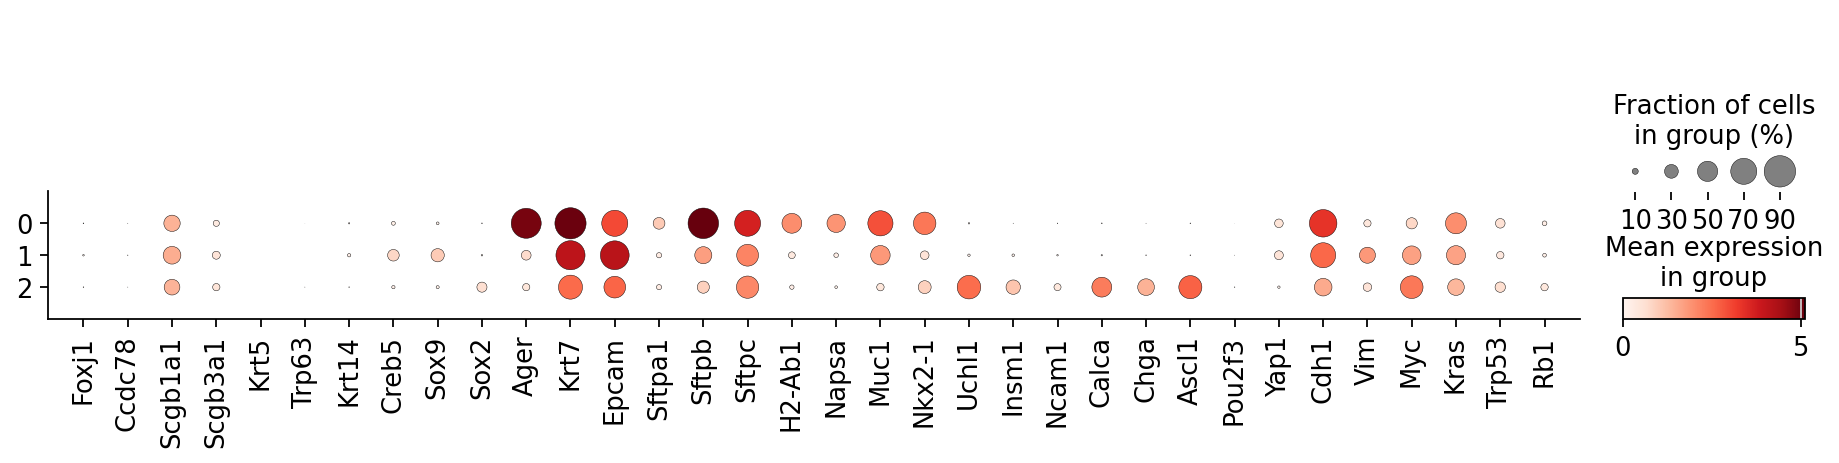

In [22]:
# marker genes的表达分析
marker_genes = ["Foxj1", "Ccdc78", "Scgb1a1", "Scgb3a1", "Krt5", "Trp63", "Krt14", "Creb5", "Sox9", "Sox2", 
"Ager", "Krt7", "Epcam", "Sftpa1", "Sftpb", "Sftpc", "H2-Ab1", "Napsa", "Muc1", "Nkx2-1",
"Uchl1", "Insm1", "Ncam1", "Calca", "Chga", "Ascl1", "Pou2f3", "Yap1", "Cdh1", "Vim", "Myc", "Kras", "Trp53", "Rb1"]
sc.pl.dotplot(ad, marker_genes, groupby='leiden')

In [23]:
new_cluster_names = ['LUAD', 'Intermediate', 'T-SCLC']
ad.obs['leiden'] = ad.obs['leiden'].cat.rename_categories(new_cluster_names)

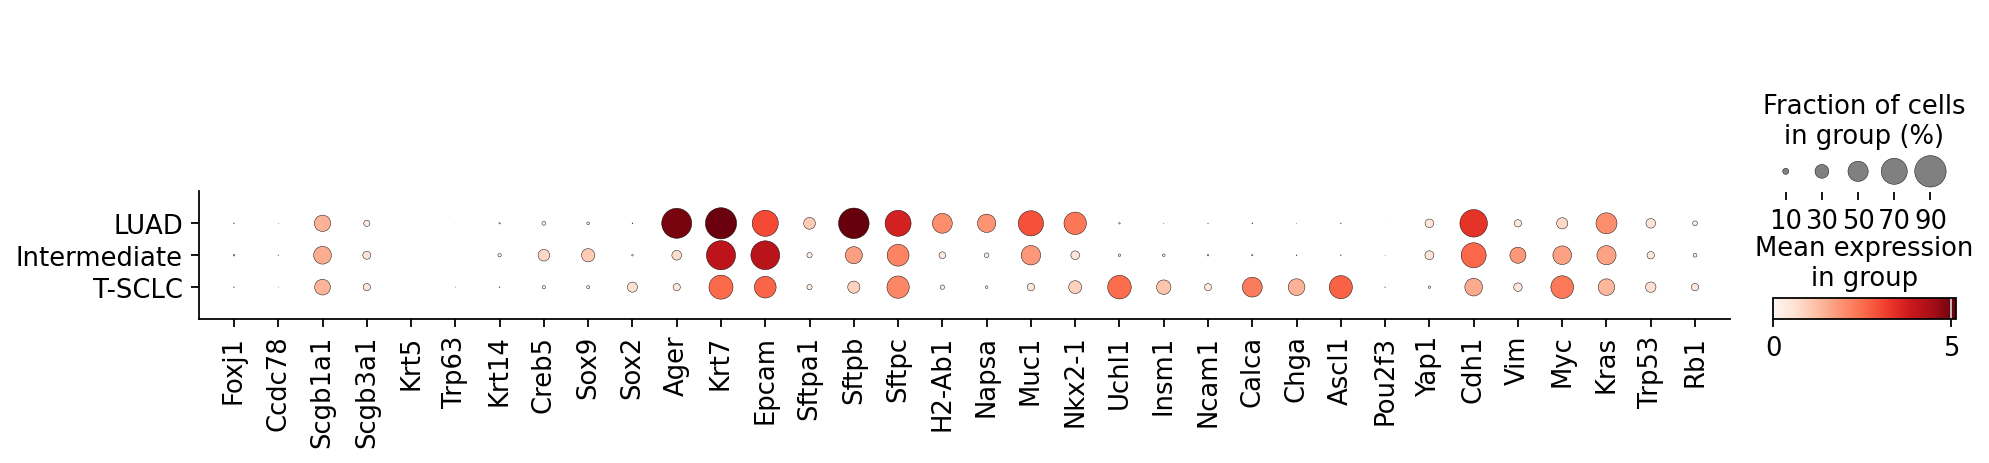

In [24]:
custom_legend_order=['LUAD', 'Intermediate', 'T-SCLC']
sc.pl.dotplot(ad, marker_genes, categories_order =custom_legend_order, groupby='leiden', save="3-3-26-dotplot.png")

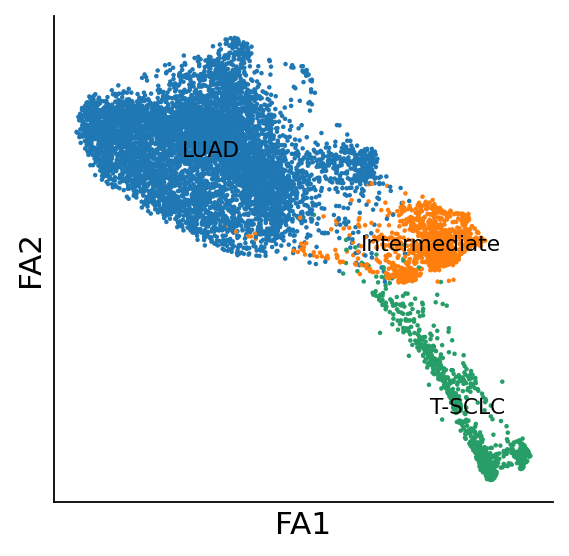

In [25]:
sc.pl.draw_graph(ad, color = "leiden", legend_loc="on data", legend_fontweight="medium",legend_fontsize="x-small",title = "",save = "3-3-26_fa.png")

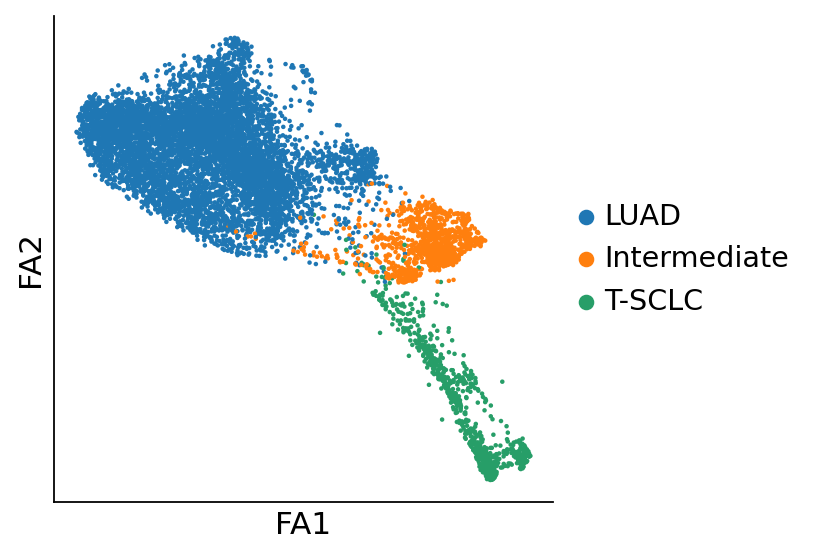

In [26]:
sc.pl.draw_graph(ad, color = "leiden",title = "",save = "fa-4.pdf")

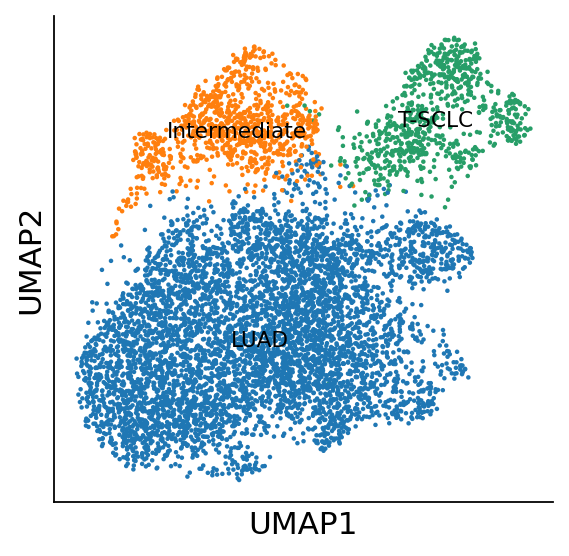

In [27]:
sc.pl.umap(ad, color='leiden', legend_loc="on data", legend_fontweight="medium",legend_fontsize="x-small",title = "")

In [28]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(ad, n_components=5)# Run diffusion maps

computing neighbors
    computing neighbors
    computed neighbors (0:00:01)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)


In [29]:
ms_data = palantir.utils.determine_multiscale_space(ad)

In [30]:
start_cell_LUAD = pd.Series(
    ["LUAD"],
    index=["KPM261_AAAGTGAGTGTCACAT-1"],
)

(<Figure size 320x320 with 1 Axes>, <Axes: >)

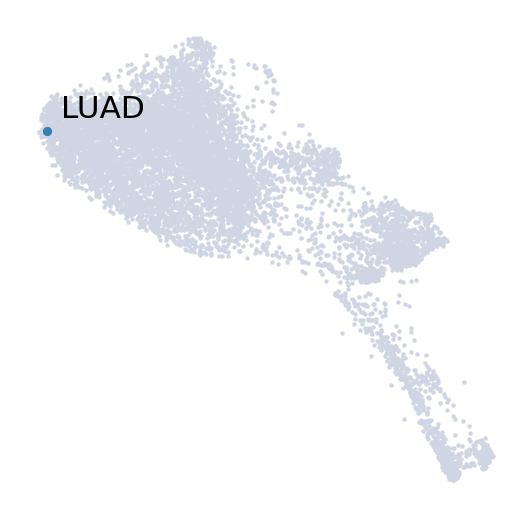

In [31]:
palantir.plot.highlight_cells_on_umap(
    # convert the draw-graph array in adata.obsm to a pandas dataframe with cells as indices and 'x','y' as columns:
    pd.DataFrame(ad.obsm['X_draw_graph_fa'], index=ad.obs.index, columns=['x','y']), 
   start_cell_LUAD
)

In [32]:
ad

AnnData object with n_obs × n_vars = 7299 × 20890
    obs: 'sample_index', 'leiden'
    var: 'genes_index', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca', 'DM_EigenValues', 'neighbors', 'umap', 'draw_graph', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_umap', 'X_draw_graph_fa'
    varm: 'PCs'
    layers: 'MAGIC_imputed_data'
    obsp: 'DM_Kernel', 'DM_Similarity', 'distances', 'connectivities'

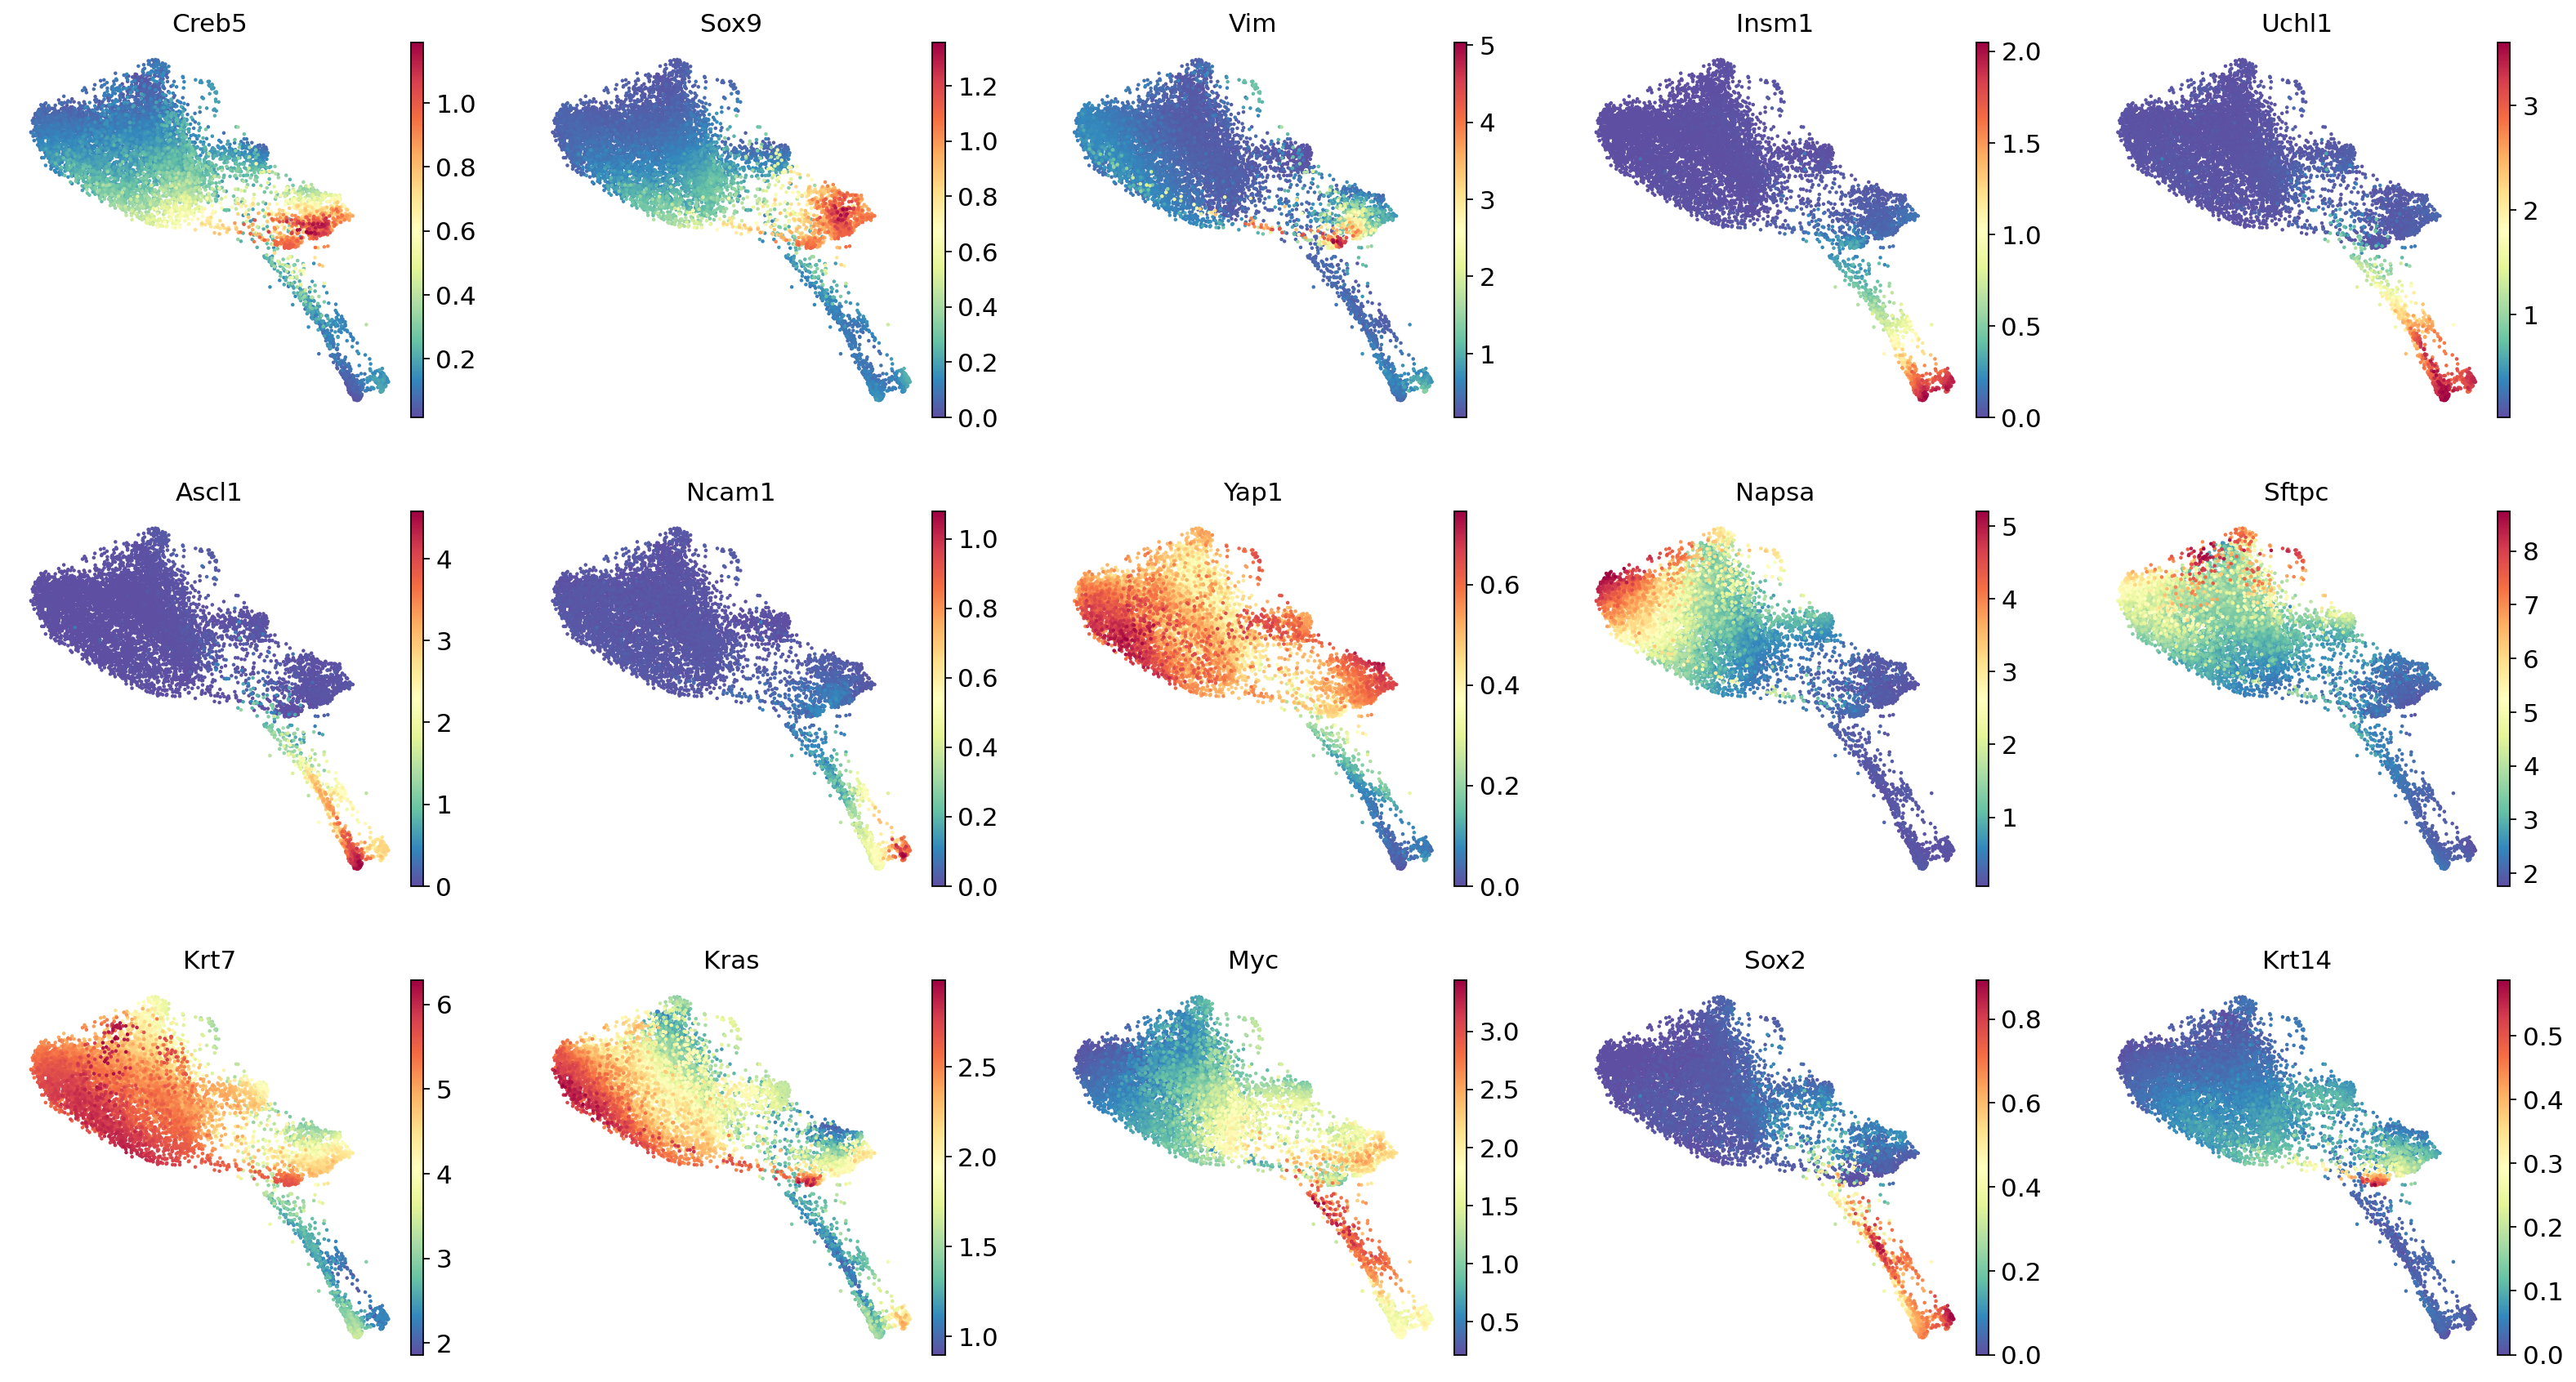

In [33]:
sc.pl.embedding(
    ad,
    basis="draw_graph_fa",
    layer="MAGIC_imputed_data",
    color=["Creb5", "Sox9", "Vim", "Insm1", "Uchl1", "Ascl1", "Ncam1", "Yap1", "Napsa", "Sftpc", "Krt7", "Kras", "Myc", "Sox2", "Krt14"],
    ncols=5,
    frameon=False,
    save="2025-4.pdf"
)
plt.show()

In [34]:
start_cell = "KPM261_AAAGTGAGTGTCACAT-1"
pr_res = palantir.core.run_palantir(
    ad, start_cell
)#LUAD

Sampling and flocking waypoints...
Time for determining waypoints: 0.0503395954767863 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...


/home/xcl/anaconda3/envs/cellrank/lib/python3.9/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
/home/xcl/anaconda3/envs/cellrank/lib/python3.9/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)
/home/xcl/anaconda3/envs/cellrank/lib/python3.9/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe

Time for shortest paths: 0.5391391714413961 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


In [35]:
from cellrank.kernels import PseudotimeKernel

pk = PseudotimeKernel(ad, time_key="palantir_pseudotime")

In [36]:
pk

PseudotimeKernel[n=7299]

In [37]:
pk.compute_transition_matrix()

  0%|          | 0/7299 [00:00<?, ?cell/s]

PseudotimeKernel[n=7299, dnorm=False, scheme='hard', frac_to_keep=0.3]

In [38]:
pk

PseudotimeKernel[n=7299, dnorm=False, scheme='hard', frac_to_keep=0.3]

In [39]:
ad

AnnData object with n_obs × n_vars = 7299 × 20890
    obs: 'sample_index', 'leiden', 'palantir_pseudotime', 'palantir_entropy'
    var: 'genes_index', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca', 'DM_EigenValues', 'neighbors', 'umap', 'draw_graph', 'leiden', 'leiden_colors', 'palantir_waypoints'
    obsm: 'X_pca', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_umap', 'X_draw_graph_fa', 'palantir_fate_probabilities'
    varm: 'PCs'
    layers: 'MAGIC_imputed_data'
    obsp: 'DM_Kernel', 'DM_Similarity', 'distances', 'connectivities'

In [40]:
from cellrank.kernels import ConnectivityKernel

ck = ConnectivityKernel(ad).compute_transition_matrix()

In [41]:
ck

ConnectivityKernel[n=7299, dnorm=True, key='connectivities']

In [42]:
combined_kernel = 0.8 * pk + 0.2 * ck
combined_kernel

(0.8 * PseudotimeKernel[n=7299, dnorm=False, scheme='hard', frac_to_keep=0.3] + 0.2 * ConnectivityKernel[n=7299, dnorm=True, key='connectivities'])

In [43]:
pk.write_to_adata()
ad.write("/home/xcl/KPM/epi_cellrank-3-26.h5ad")

In [44]:
adata = sc.read("/home/xcl/KPM/epi_cellrank-3-26.h5ad")
pk_new = cr.kernels.PseudotimeKernel.from_adata(adata, key="T_fwd")
pk_new

PseudotimeKernel[n=7299, dnorm=False, frac_to_keep=0.3, scheme='hard']

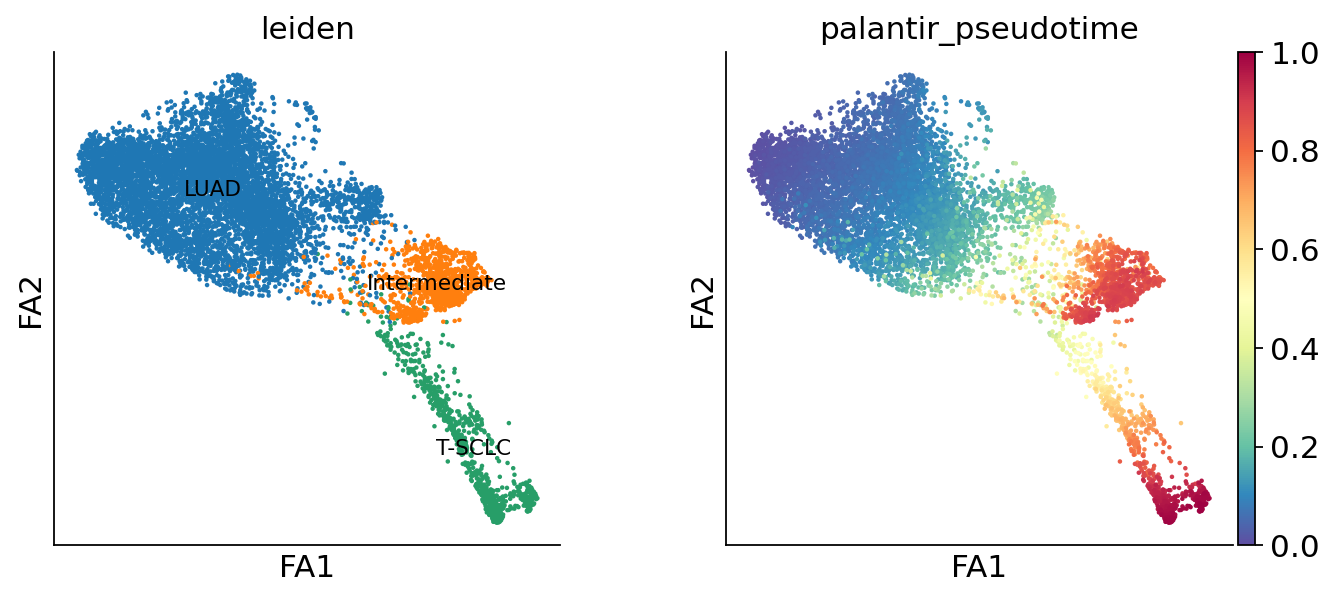

In [45]:
sc.pl.embedding(adata, basis="draw_graph_fa", color=["leiden", "palantir_pseudotime"],legend_loc='on data',legend_fontweight="medium",legend_fontsize="x-small",save="palantir-LUAD-3-26.png")

In [46]:
from cellrank.estimators import GPCCA

g = GPCCA(pk_new)
print(g)

GPCCA[kernel=PseudotimeKernel[n=7299], initial_states=None, terminal_states=None]


In [47]:
sc.set_figure_params(figsize=(4,4))
plt.tight_layout()

<Figure size 320x320 with 0 Axes>

/home/xcl/anaconda3/envs/cellrank/lib/python3.9/site-packages/scvelo/plotting/scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


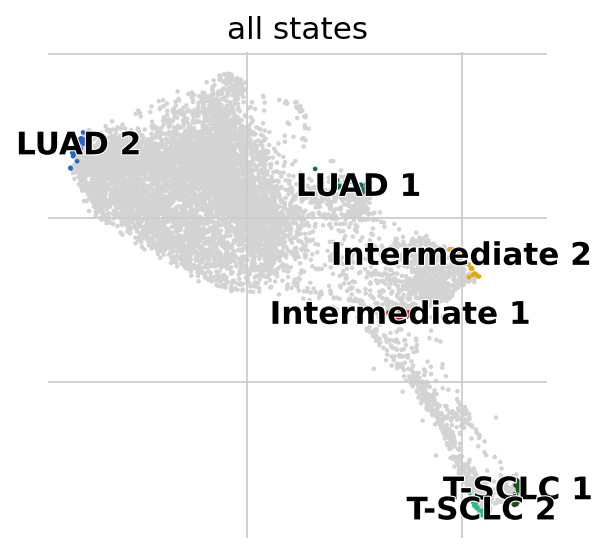

In [48]:
g.fit(n_states=6, cluster_key="leiden")
g.plot_macrostates(which="all",basis="draw_graph_fa")

/home/xcl/anaconda3/envs/cellrank/lib/python3.9/site-packages/scvelo/plotting/scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


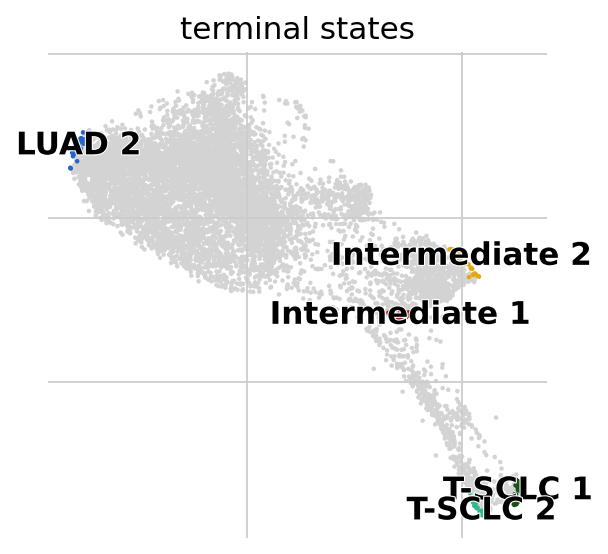

In [49]:
g.predict_terminal_states(method="top_n", n_states=5)
g.plot_macrostates(which="terminal",basis="draw_graph_fa")

  0%|          | 0/5 [00:00<?, ?/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0
/home/xcl/anaconda3/envs/cellrank/lib/python3.9/site-packages/scvelo/plotting/scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/home/xcl/anaconda3/envs/cellrank/lib/python3.9/site-packages/scvelo/plotting/scatter.py:655: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter

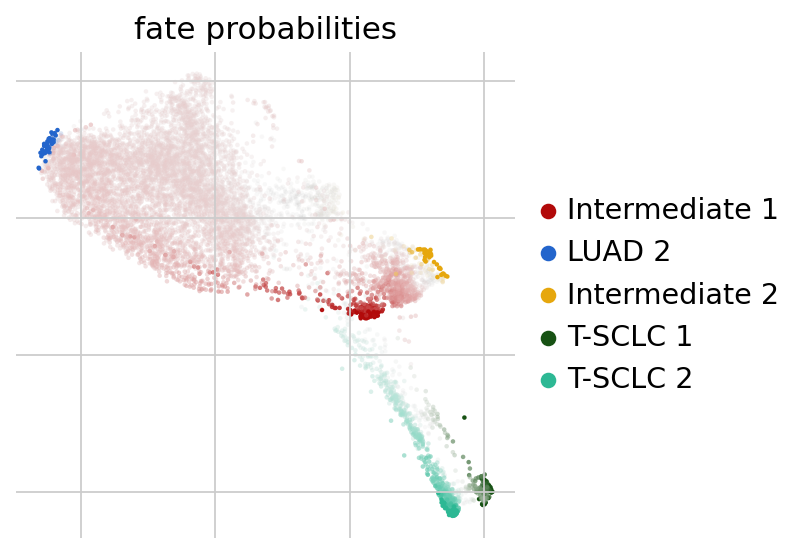

In [50]:
g.compute_fate_probabilities()
g.plot_fate_probabilities(legend_loc="right",basis="draw_graph_fa")

In [51]:
model = cr.models.GAM(adata)

In [52]:
print(adata.obsm.keys())

KeysView(AxisArrays with keys: DM_EigenVectors, DM_EigenVectors_multiscaled, X_draw_graph_fa, X_pca, X_umap, palantir_fate_probabilities, schur_vectors_fwd, macrostates_fwd_memberships, term_states_fwd_memberships, lineages_fwd)


  0%|          | 0/4 [00:00<?, ?gene/s]

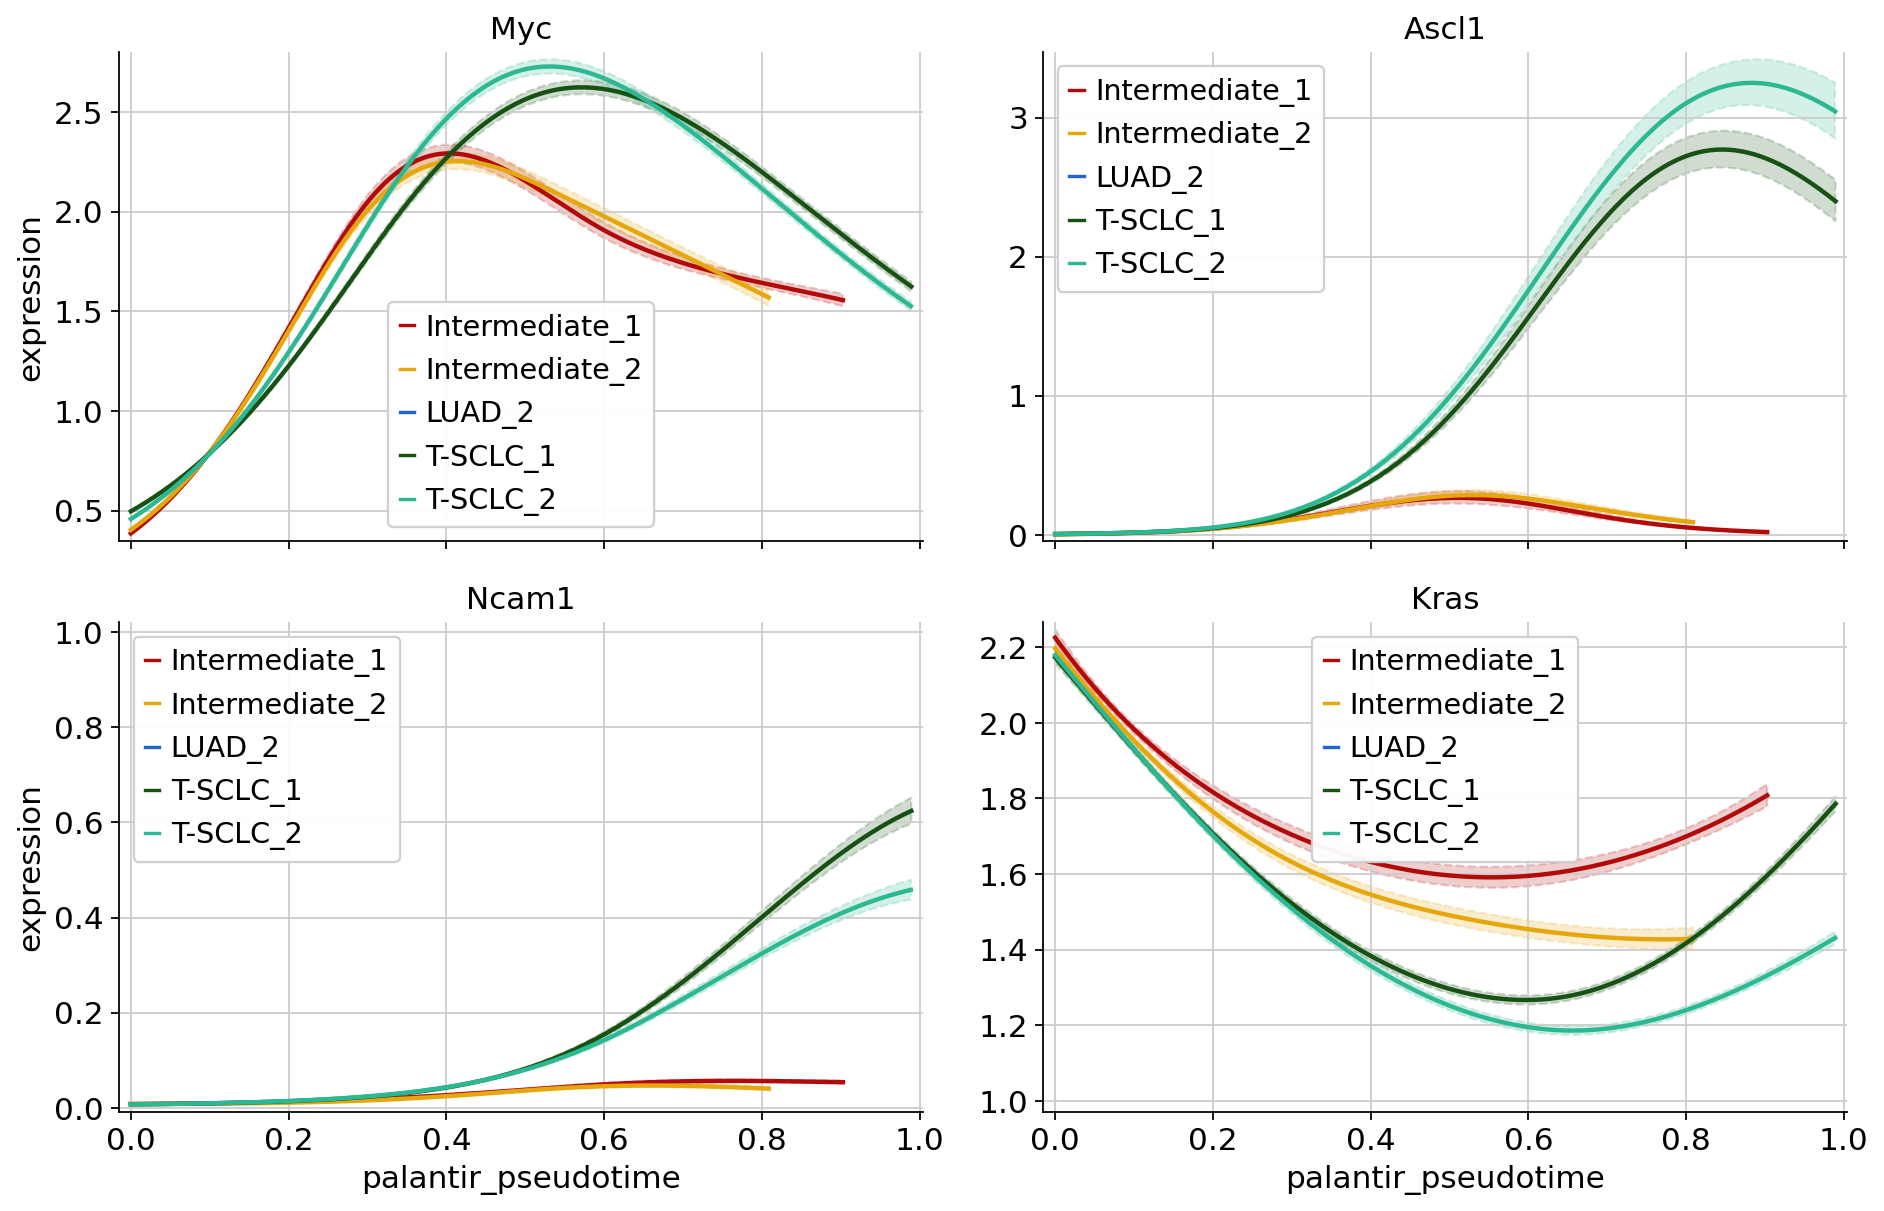

In [53]:
cr.pl.gene_trends(
    adata,
    model=model,
    data_key="MAGIC_imputed_data",
    genes=["Myc", "Ascl1","Ncam1","Kras"],
    same_plot=True,
    ncols=2,
    time_key="palantir_pseudotime",
    hide_cells=True,
)

In [54]:
plt.rcParams["axes.grid"] = False

  0%|          | 0/34 [00:00<?, ?gene/s]

did not converge


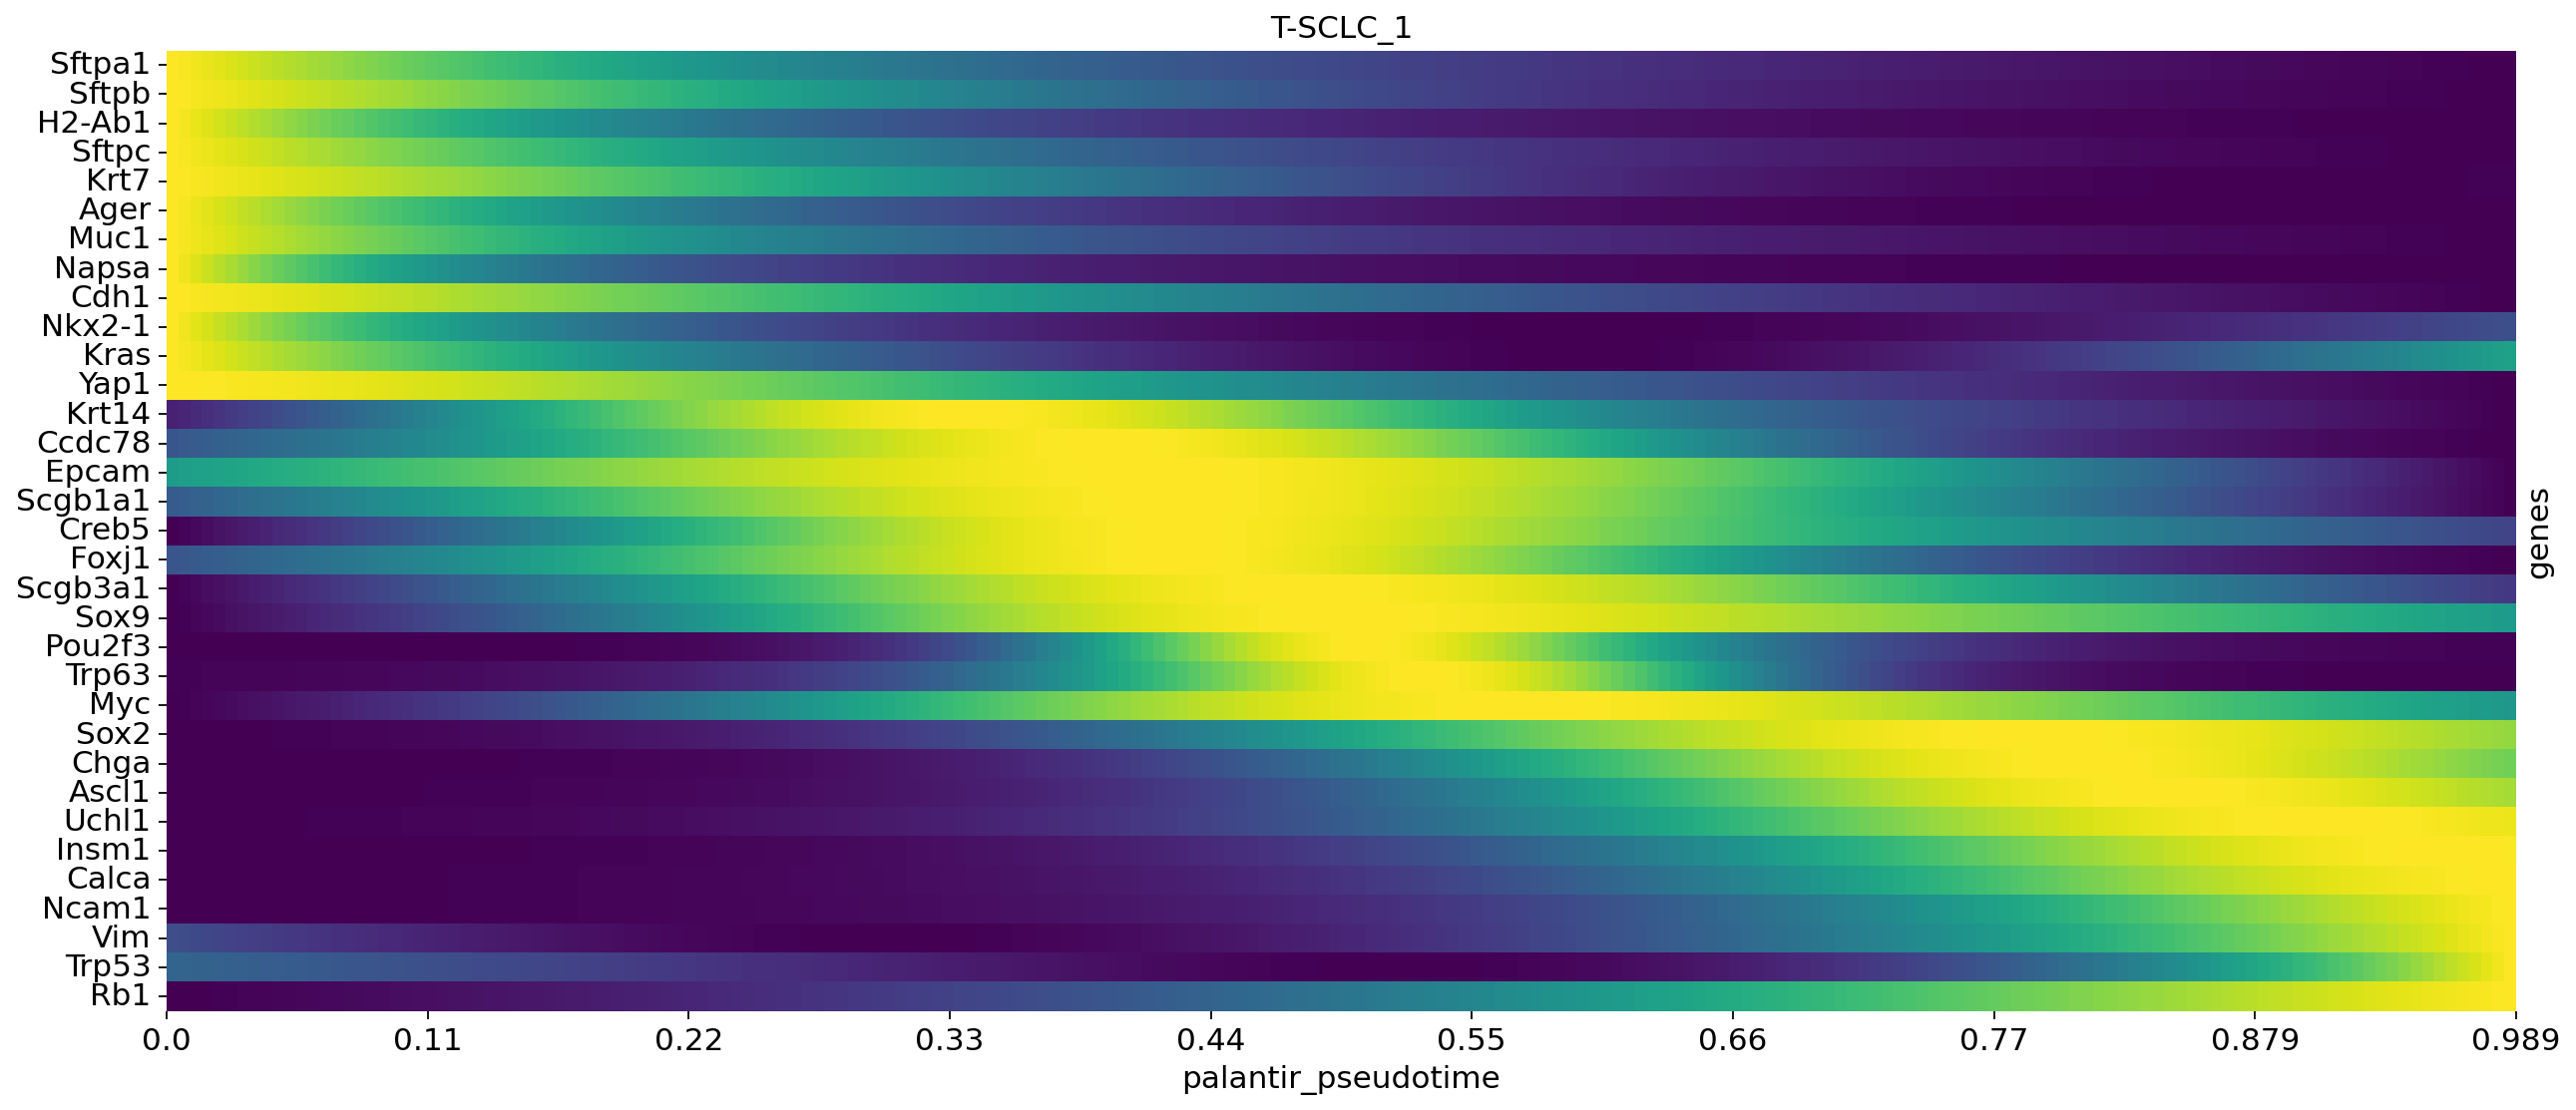

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.


In [55]:
cr.pl.heatmap(
    adata,
    model=model,
    data_key="MAGIC_imputed_data",
    genes=["Foxj1", "Ccdc78", "Scgb1a1", "Scgb3a1", "Krt5", "Trp63", "Krt14", "Creb5", "Sox9", "Sox2", 
"Ager", "Krt7", "Epcam", "Sftpa1", "Sftpb", "Sftpc", "H2-Ab1", "Napsa", "Muc1", "Nkx2-1",
"Uchl1", "Insm1", "Ncam1", "Calca", "Chga", "Ascl1", "Pou2f3", "Yap1", "Cdh1", "Vim", "Myc", "Kras", "Trp53", "Rb1"],
    lineages=["T-SCLC_1"],
    time_key="palantir_pseudotime",
    cbar=False,
    show_all_genes=True,
    figsize=(20,8),
    save="heatmap-epi-3-26.png"
)

  0%|          | 0/8 [00:00<?, ?gene/s]

did not converge


[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


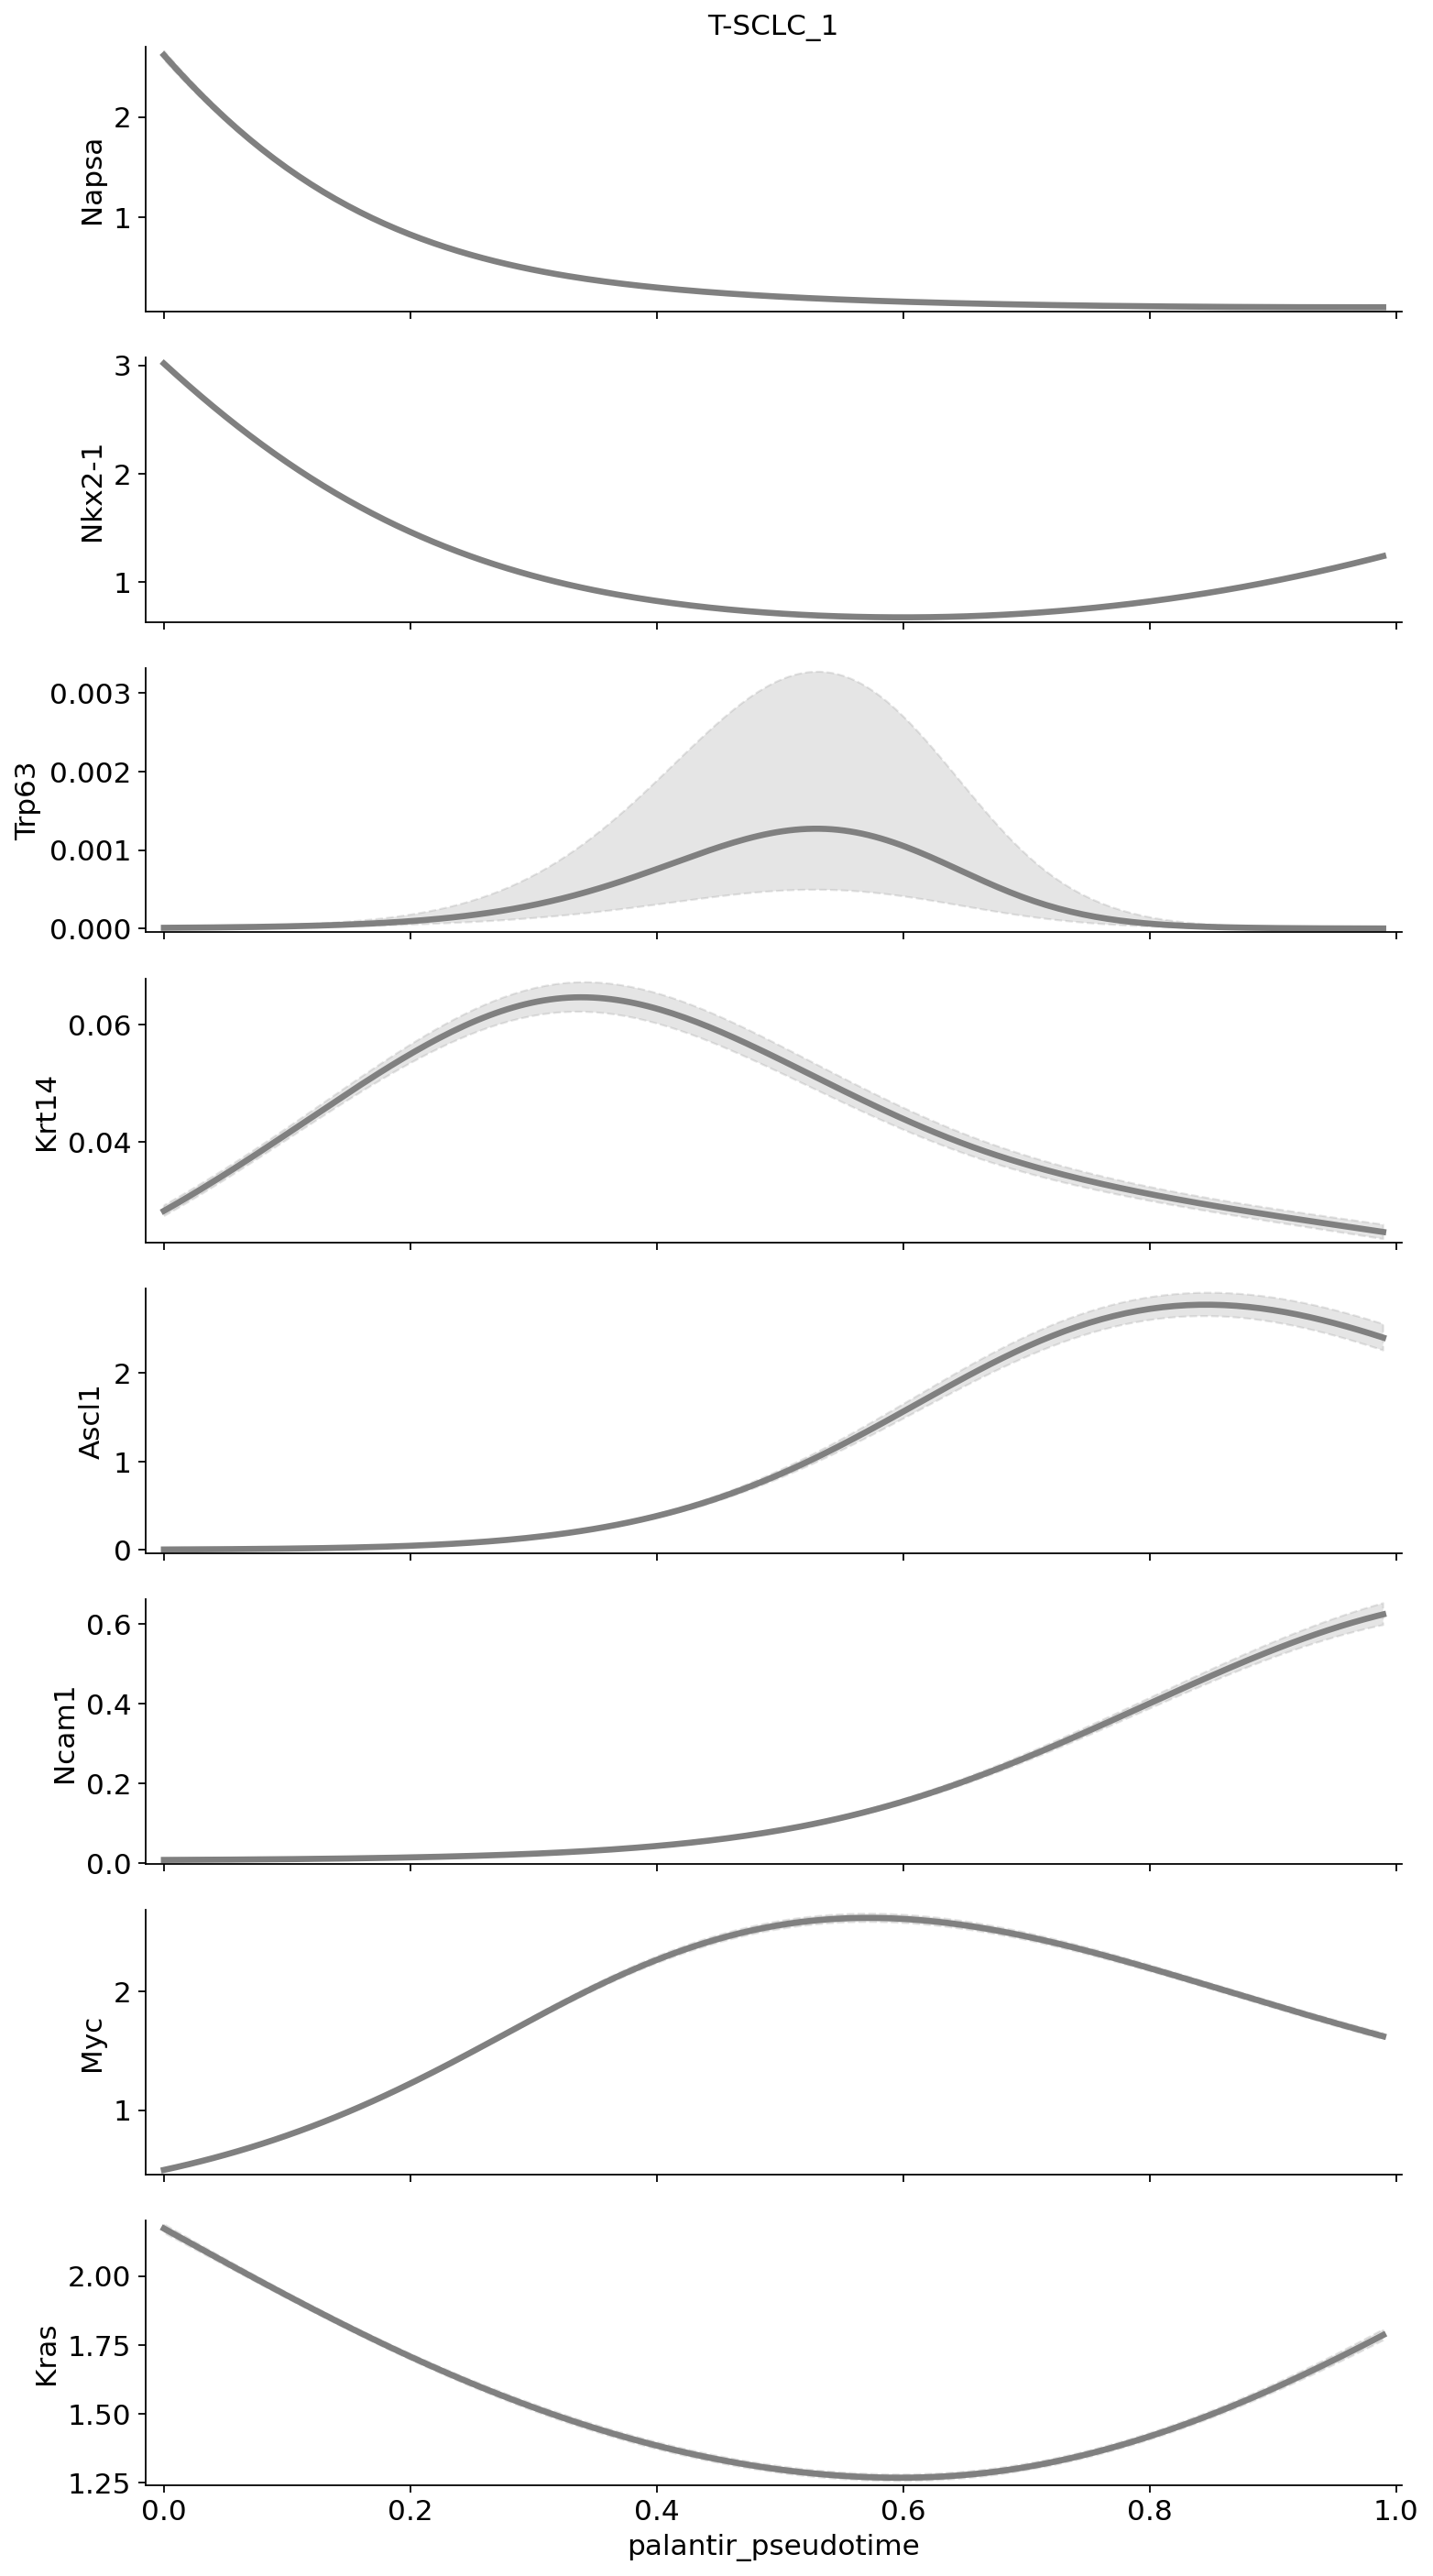

In [56]:
cr.pl.gene_trends(
    adata,
    model=model,
    data_key="MAGIC_imputed_data",
    genes=["Napsa", "Nkx2-1", "Trp63", "Krt14","Ascl1", "Ncam1", "Myc", "Kras"],
    lineages="T-SCLC_1",
    lineage_cmap="Grey",
    ncols=2,
    time_key="palantir_pseudotime",
    figsize=(10,18),
    hide_cells=True,
    lw=3,
    save = "trend curve.pdf"
)

  0%|          | 0/5 [00:00<?, ?gene/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


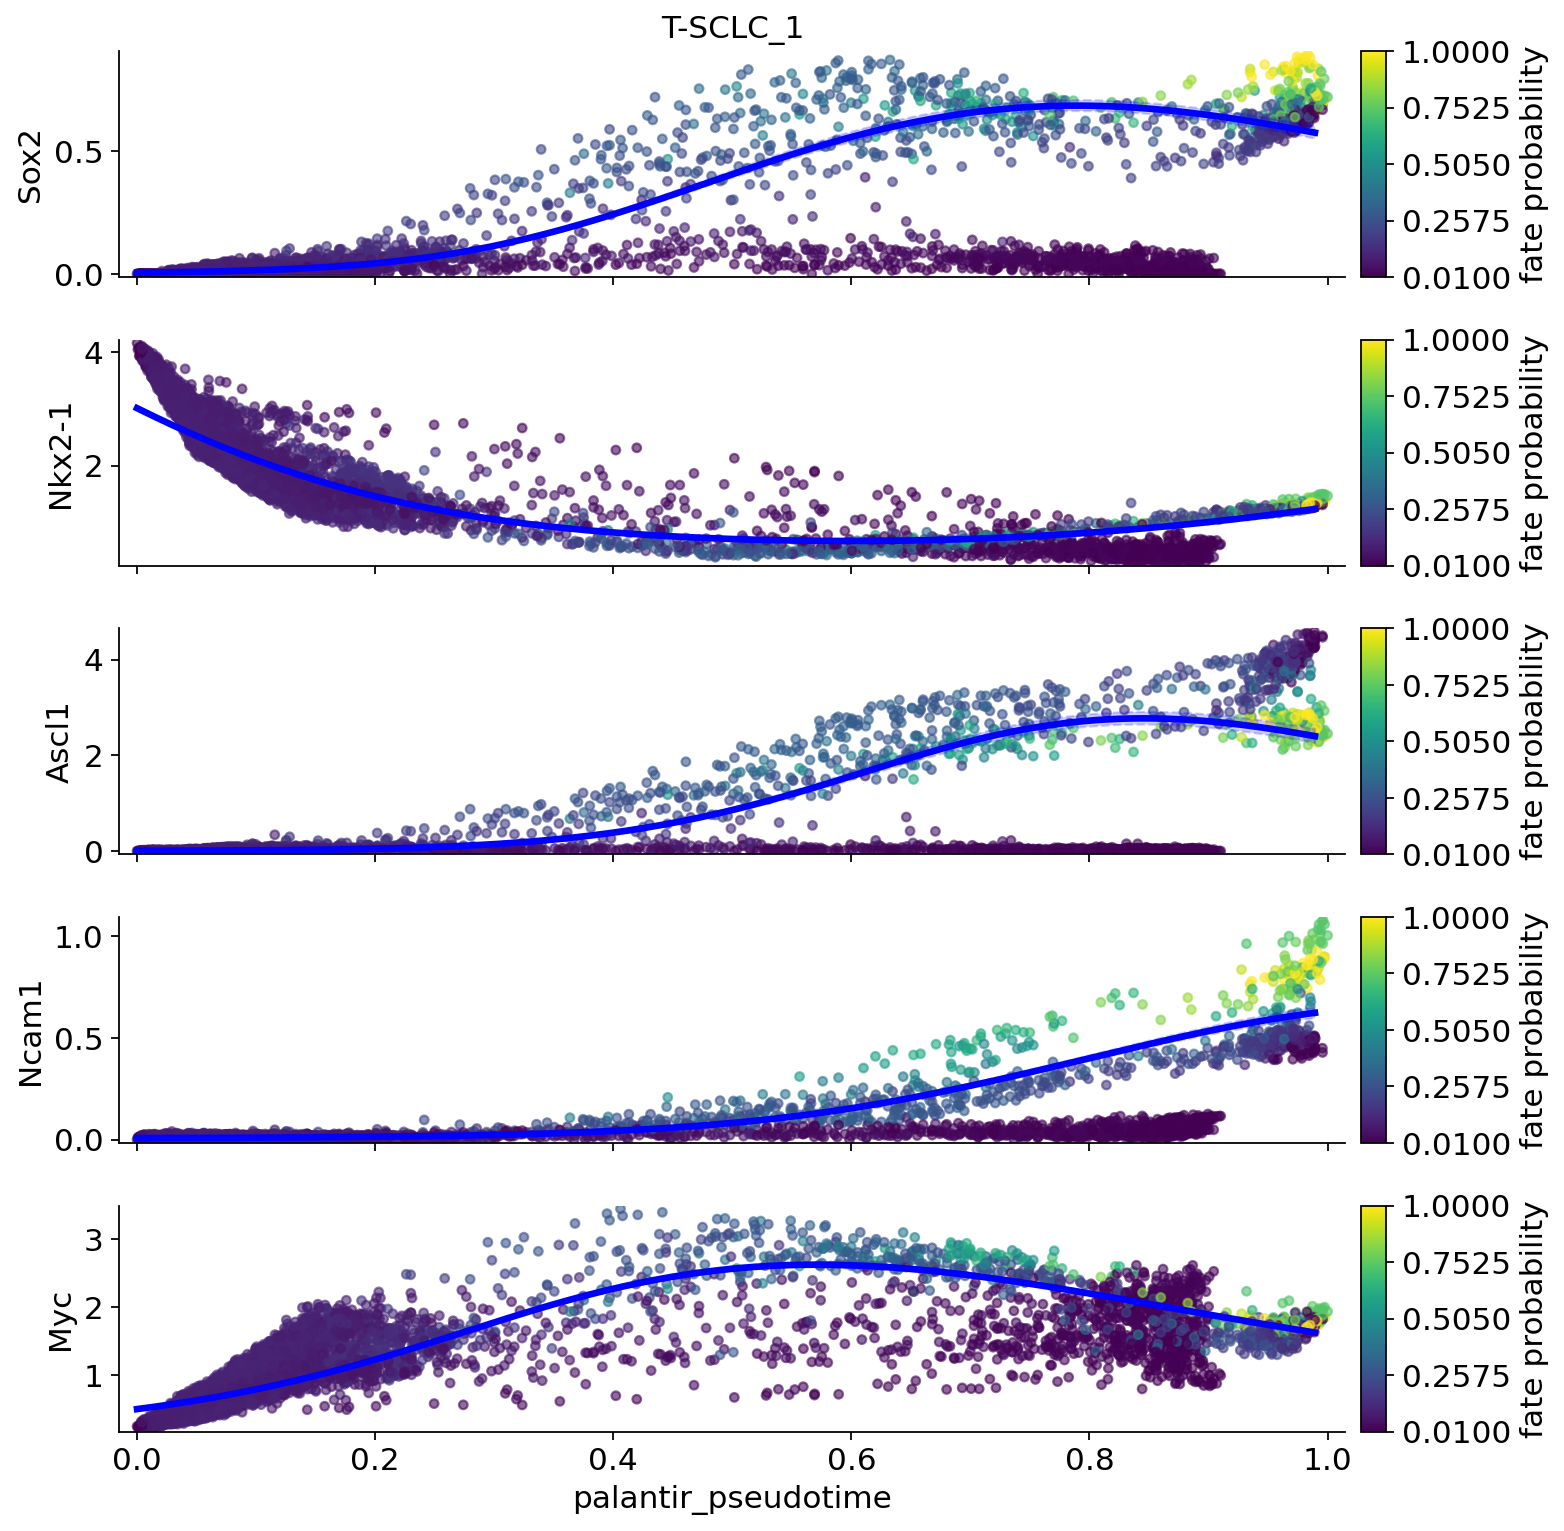

In [57]:
cr.pl.gene_trends(
    adata,
    model=model,
    data_key="MAGIC_imputed_data",
    genes=["Sox2", "Nkx2-1","Ascl1", "Ncam1", "Myc"],
    lineages="T-SCLC_1",
    lineage_cmap="blue",
    ncols=2,
    time_key="palantir_pseudotime",
    figsize=(10,10),
    lw=3,
    save = "trend-blue-3.pdf"
)

In [58]:
pip list

Package                   Version
------------------------- --------------
absl-py                   2.1.0
adjustText                1.1.1
aiohttp                   3.9.3
aiosignal                 1.3.1
alembic                   1.13.2
anndata                   0.10.5.post1
annotated-types           0.7.0
annoy                     1.17.3
anyio                     4.2.0
arboreto                  0.1.6
argon2-cffi               21.3.0
argon2-cffi-bindings      21.2.0
array_api_compat          1.5
arrow                     1.3.0
asttokens                 2.0.5
async-generator           1.10
async-lru                 2.0.4
async-timeout             4.0.3
attrs                     23.1.0
Babel                     2.11.0
backcall                  0.2.0
beautifulsoup4            4.12.2
bleach                    4.1.0
blessed                   1.20.0
blinker                   1.7.0
blis                      0.7.11
bokeh                     3.4.1
boltons                   24.0.0
Brotli         